# Spectrum M4i.6622: continuous phase-coherent AOD multitone replay

This self-contained notebook generates the **initial 20-tone state only**, pre-uploads one periodic segment to a Spectrum M4i.6622, and continuously replays it in sequence mode after a software trigger. It does not play an atom-rearrangement cycle and does not use FIFO streaming.

> **Safety:** hardware execution is disabled by default. Check the configured channel range and connect a correctly terminated 50 Ω measurement load before setting `RUN_HARDWARE = True`.

In [1]:
from dataclasses import dataclass
from fractions import Fraction
from functools import reduce
from math import gcd, lcm
import time

import numpy as np
import matplotlib.pyplot as plt

import spcm
from spcm import units

plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True})

@dataclass(frozen=True)
class AWGConfig:
    card_resource: str = "/dev/spcm0"
    channel: int = 0
    sample_rate_hz: int = 625_000_000
    output_amplitude_mv: float = 1000.0  # Full-scale channel range into 50 ohm.
    output_load_ohm: int = 50

    n_tones: int = 20
    f_min_hz: int = 80_000_000
    f_max_hz: int = 120_000_000
    tone_amplitude: float = 1.0
    phi1_rad: float = 0.0

    dac_headroom: float = 0.95
    dac_max_code: int = 32767
    segment_alignment_samples: int = 32

CFG = AWGConfig()
print(CFG)

AWGConfig(card_resource='/dev/spcm0', channel=0, sample_rate_hz=625000000, output_amplitude_mv=1000.0, output_load_ohm=50, n_tones=20, f_min_hz=80000000, f_max_hz=120000000, tone_amplitude=1.0, phi1_rad=0.0, dac_headroom=0.95, dac_max_code=32767, segment_alignment_samples=32)


## 1. Weighted-Schroeder initialization

The phase rule and crest-factor helper are reused from `AOD Parallel Rearrangement.ipynb`. Equal tone amplitudes are used here, but the generator accepts arbitrary nonnegative weights.

In [9]:
def calculate_cf(x):
    """Return peak, RMS, crest factor, crest factor in dB, and PAPR."""
    x = np.asarray(x, dtype=float)
    if x.size == 0 or not np.all(np.isfinite(x)):
        raise ValueError("waveform must be nonempty and finite")
    peak = float(np.max(np.abs(x)))
    rms = float(np.sqrt(np.mean(x**2)))
    if rms == 0:
        raise ValueError("crest factor is undefined for a zero-RMS waveform")
    cf = peak / rms
    return peak, rms, cf, 20*np.log10(cf), cf**2


def phase_weighted_schroeder(amps, phi1=0.0):
    """Return power-weighted Schroeder phases in [0, 2*pi)."""
    amps = np.asarray(amps, dtype=float)
    # if amps.ndim != 1 or not np.all(np.isfinite(amps)):
    #     raise ValueError("amps must be a finite 1D array")
    # if amps.size == 0:
    #     return np.empty(0, dtype=float)
    # if np.any(amps < 0):
    #     raise ValueError("amps must be nonnegative")
    total_power = float(np.sum(amps**2))
    # if total_power <= 0:
    #     raise ValueError("weighted Schroeder phases require positive total power")
    p = amps**2 / total_power
    phi = np.zeros(len(amps), dtype=float)
    phi[0] = phi1
    for m in range(1, len(amps)):
        phi[m] = phi1 + 2*np.pi*sum((m-i)*p[i] for i in range(m))
    return np.mod(phi, 2*np.pi)


def wrapped_phase_error(actual, target):
    return np.angle(np.exp(1j*(np.asarray(actual) - np.asarray(target))))

## 2. Construct an exactly periodic, aligned segment

A replay wrap is phase-continuous only if every tone completes an integer number of cycles in the segment. Frequencies are therefore retained as exact rational values while calculating the common period. The common phase recurrence is combined with the card segment alignment using an LCM; no zero-padding is added because padding would break phase continuity.

In [14]:
def exact_frequency_grid(cfg=CFG):
    if cfg.n_tones < 1:
        raise ValueError("n_tones must be positive")
    if cfg.n_tones == 1:
        return [Fraction(cfg.f_min_hz)]
    spacing = Fraction(cfg.f_max_hz - cfg.f_min_hz, cfg.n_tones - 1)
    return [Fraction(cfg.f_min_hz) + i*spacing for i in range(cfg.n_tones)]


def common_phase_period_samples(frequencies_hz, sample_rate_hz):
    """Smallest N for which N*f/fs is an integer for every exact frequency."""
    fs = Fraction(sample_rate_hz)
    denominators = [(Fraction(f) / fs).denominator for f in frequencies_hz]
    return reduce(lcm, denominators, 1)


def build_periodic_multitone(cfg=CFG):
    # if cfg.sample_rate_hz <= 0 or cfg.segment_alignment_samples <= 0:
    #     raise ValueError("sample rate and segment alignment must be positive")
    exact_freqs = exact_frequency_grid(cfg)
    if any(f <= 0 or f >= Fraction(cfg.sample_rate_hz, 2) for f in exact_freqs):
        raise ValueError("all tones must lie strictly between DC and Nyquist")

    base_period = common_phase_period_samples(exact_freqs, cfg.sample_rate_hz)
    loop_samples = lcm(base_period, cfg.segment_alignment_samples)
    frequencies_hz = np.array([float(f) for f in exact_freqs])
    amplitudes = np.full(cfg.n_tones, cfg.tone_amplitude, dtype=float)
    # print(amplitudes)
    phases = phase_weighted_schroeder(amplitudes, cfg.phi1_rad)

    n = np.arange(loop_samples, dtype=np.float64)
    phase_matrix = phases[:, None] + 2*np.pi*frequencies_hz[:, None]*n/cfg.sample_rate_hz
    waveform = np.sum(amplitudes[:, None]*np.cos(phase_matrix), axis=0)

    exact_cycles = [f*loop_samples/Fraction(cfg.sample_rate_hz) for f in exact_freqs]
    if not all(c.denominator == 1 for c in exact_cycles):
        raise RuntimeError("chosen segment does not close every tone phase")

    next_phase = phases + 2*np.pi*frequencies_hz*loop_samples/cfg.sample_rate_hz
    next_sample = float(np.sum(amplitudes*np.cos(next_phase)))
    wrap_error = next_sample - float(waveform[0])
    return {
        "waveform": waveform,
        "frequencies_hz": frequencies_hz,
        "exact_frequencies_hz": exact_freqs,
        "amplitudes": amplitudes,
        "initial_phases_rad": phases,
        "base_period_samples": base_period,
        "loop_samples": loop_samples,
        "exact_cycles": exact_cycles,
        "next_sample": next_sample,
        "wrap_error": wrap_error,
    }

In [15]:
signal = build_periodic_multitone(CFG)
peak, rms, cf, cf_db, papr = calculate_cf(signal["waveform"])

print(f"Tones: {CFG.n_tones}, {signal['frequencies_hz'][0]/1e6:.3f} to "
      f"{signal['frequencies_hz'][-1]/1e6:.3f} MHz")
print(f"Base phase recurrence: {signal['base_period_samples']:,} samples")
print(f"Aligned replay segment: {signal['loop_samples']:,} samples "
      f"({signal['loop_samples']/CFG.sample_rate_hz*1e6:.3f} us)")
print(f"All tones have integer cycles: {all(c.denominator == 1 for c in signal['exact_cycles'])}")
print(f"Implied x[N] - x[0]: {signal['wrap_error']:.3e}")
print(f"Peak={peak:.6f}, RMS={rms:.6f}, CF={cf:.4f} ({cf_db:.3f} dB), PAPR={papr:.4f}")

assert signal['loop_samples'] % CFG.segment_alignment_samples == 0
assert abs(signal['wrap_error']) < 1e-8
assert np.all(np.isfinite(signal['waveform']))

Tones: 20, 80.000 to 120.000 MHz
Base phase recurrence: 2,375 samples
Aligned replay segment: 76,000 samples (121.600 us)
All tones have integer cycles: True
Implied x[N] - x[0]: 2.862e-11
Peak=6.036065, RMS=3.162278, CF=1.9088 (5.615 dB), PAPR=3.6434


## 3. Standalone phase-continuity diagnostic

This plotting helper is deliberately separate from waveform generation and from the AWG class. It only visualizes the mathematical continuation across one replay boundary; it does not modify the uploaded segment.

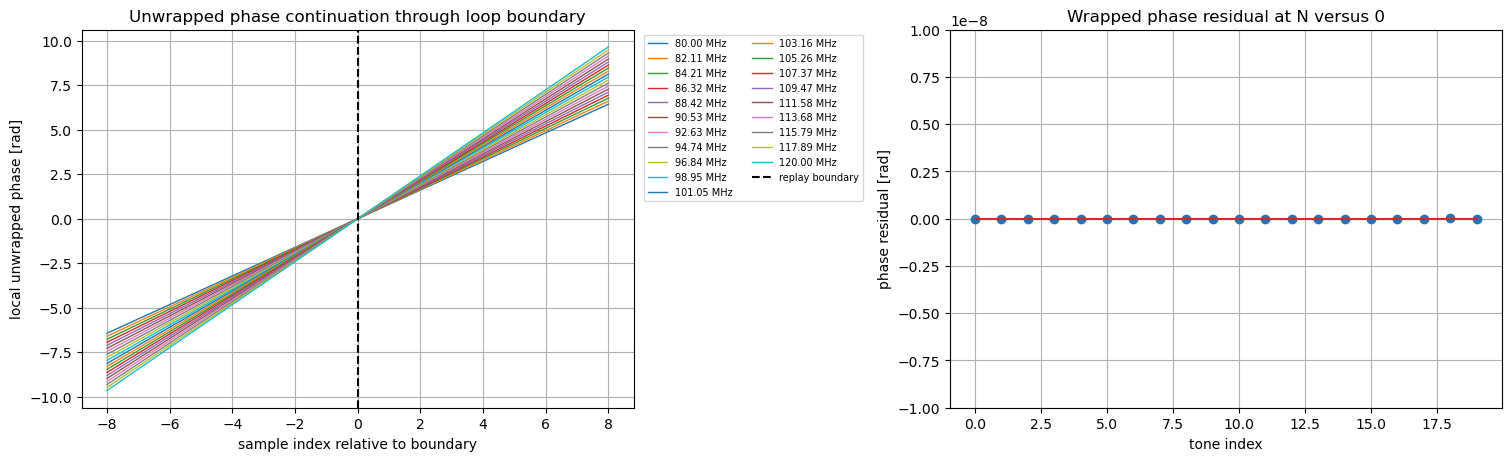

Maximum wrapped per-tone phase residual: 1.405e-11 rad


In [5]:
def plot_phase_continuity(frequencies_hz, initial_phases_rad, sample_rate_hz,
                          loop_samples, window_samples=8):
    frequencies_hz = np.asarray(frequencies_hz, dtype=float)
    initial_phases_rad = np.asarray(initial_phases_rad, dtype=float)
    if frequencies_hz.shape != initial_phases_rad.shape:
        raise ValueError("frequency and phase arrays must have matching shapes")
    if window_samples < 1:
        raise ValueError("window_samples must be positive")

    # Extend n beyond N instead of resetting phase at the replay boundary.
    n = np.arange(loop_samples-window_samples, loop_samples+window_samples+1)
    phase = initial_phases_rad[:, None] + 2*np.pi*frequencies_hz[:, None]*n/sample_rate_hz
    boundary_phase = initial_phases_rad + 2*np.pi*frequencies_hz*loop_samples/sample_rate_hz
    residual = wrapped_phase_error(boundary_phase, initial_phases_rad)

    fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), constrained_layout=True)
    x = n-loop_samples
    for tone, row in enumerate(phase):
        # Subtract each tone's phase at N so all local trajectories remain readable.
        axes[0].plot(x, row-boundary_phase[tone], lw=1, label=f"{frequencies_hz[tone]/1e6:.2f} MHz")
    axes[0].axvline(0, color='k', ls='--', label='replay boundary')
    axes[0].set(title='Unwrapped phase continuation through loop boundary',
                xlabel='sample index relative to boundary', ylabel='local unwrapped phase [rad]')
    axes[0].legend(ncol=2, fontsize=7, loc='upper left', bbox_to_anchor=(1.01, 1.0))

    markerline, stemlines, baseline = axes[1].stem(np.arange(len(residual)), residual)
    axes[1].set(title='Wrapped phase residual at N versus 0', xlabel='tone index',
                ylabel='phase residual [rad]')
    axes[1].set_ylim(-1e-8, 1e-8) if np.max(np.abs(residual)) < 1e-8 else None
    plt.show()
    return residual


phase_residual = plot_phase_continuity(
    signal['frequencies_hz'], signal['initial_phases_rad'], CFG.sample_rate_hz,
    signal['loop_samples']
)
print(f"Maximum wrapped per-tone phase residual: {np.max(np.abs(phase_residual)):.3e} rad")

## 4. DAC conversion and waveform diagnostics

The floating multitone is peak-normalized to a configurable fraction of DAC full scale. `output_amplitude_mv` controls the card's physical full-scale channel range; `dac_headroom` controls how much of that range the samples use. Thus the waveform peak is approximately `dac_headroom × output_amplitude_mv` under the card's range convention.

DAC samples: 76,000, dtype=int16
Largest code: 31,129 / 32,767
Configured channel range: 1000.0 mV into 50 ohm


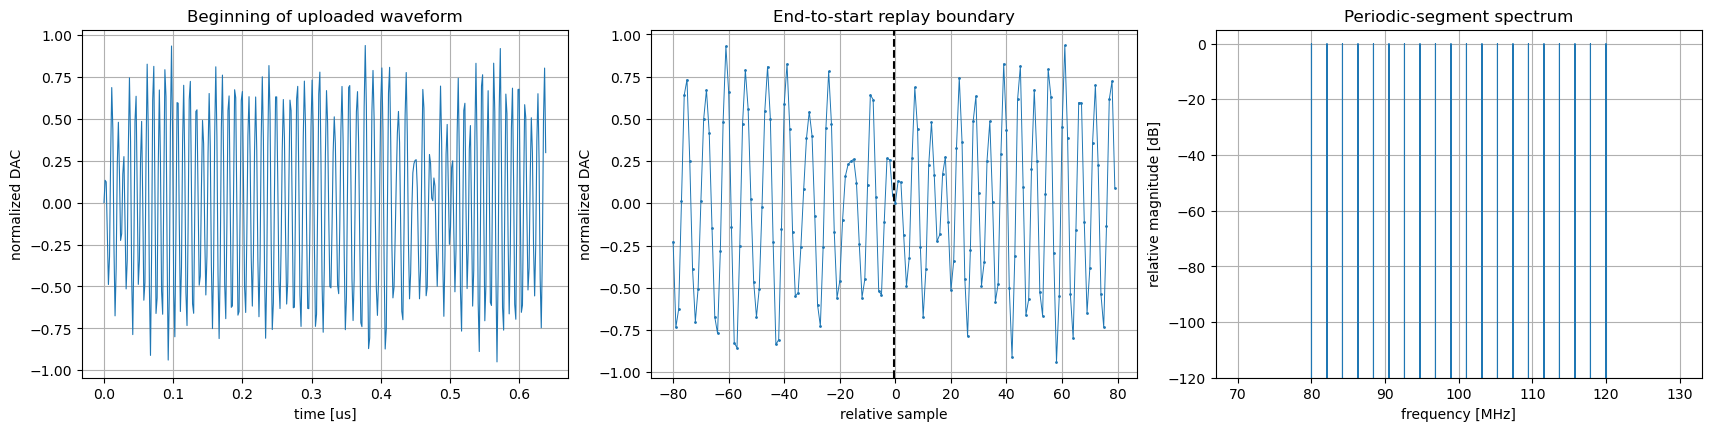

In [6]:
@dataclass(frozen=True)
class DACConversion:
    samples: np.ndarray
    normalized: np.ndarray
    input_peak: float
    normalization_scale: float
    max_code_used: int


def float_to_dac(waveform, max_code=32767, headroom=0.95):
    waveform = np.asarray(waveform, dtype=np.float64)
    if waveform.ndim != 1 or waveform.size == 0 or not np.all(np.isfinite(waveform)):
        raise ValueError("waveform must be a nonempty finite 1D array")
    if not (0 < headroom <= 1):
        raise ValueError("headroom must be in (0, 1]")
    if not (1 <= int(max_code) <= np.iinfo(np.int16).max):
        raise ValueError("max_code must fit signed int16")
    peak = float(np.max(np.abs(waveform)))
    if peak == 0:
        raise ValueError("cannot scale a zero waveform")
    normalized = waveform / peak * headroom
    if np.max(np.abs(normalized)) > 1 + 10*np.finfo(float).eps:
        raise RuntimeError("normalization produced clipping")
    samples = np.rint(normalized*int(max_code)).astype(np.int16)
    return DACConversion(samples, normalized, peak, peak/headroom,
                         int(np.max(np.abs(samples.astype(np.int32)))))


dac = float_to_dac(signal['waveform'], CFG.dac_max_code, CFG.dac_headroom)
print(f"DAC samples: {dac.samples.size:,}, dtype={dac.samples.dtype}")
print(f"Largest code: {dac.max_code_used:,} / {CFG.dac_max_code:,}")
print(f"Configured channel range: {CFG.output_amplitude_mv:.1f} mV into {CFG.output_load_ohm} ohm")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.2), constrained_layout=True)
view = min(400, dac.normalized.size)
axes[0].plot(np.arange(view)/CFG.sample_rate_hz*1e6, dac.normalized[:view], lw=.8)
axes[0].set(title='Beginning of uploaded waveform', xlabel='time [us]', ylabel='normalized DAC')

edge = 80
wrapped_view = np.concatenate([dac.normalized[-edge:], dac.normalized[:edge]])
axes[1].plot(np.arange(-edge, edge), wrapped_view, '.-', ms=2, lw=.7)
axes[1].axvline(-0.5, color='k', ls='--')
axes[1].set(title='End-to-start replay boundary', xlabel='relative sample', ylabel='normalized DAC')

spectrum = np.abs(np.fft.rfft(dac.normalized))
fft_freq = np.fft.rfftfreq(dac.normalized.size, 1/CFG.sample_rate_hz)
spectrum_db = 20*np.log10(np.maximum(spectrum/np.max(spectrum), 1e-14))
band = (fft_freq >= 70e6) & (fft_freq <= 130e6)
axes[2].plot(fft_freq[band]/1e6, spectrum_db[band], lw=.8)
axes[2].set(title='Periodic-segment spectrum', xlabel='frequency [MHz]',
            ylabel='relative magnitude [dB]', ylim=(-120, 5))
plt.show()

## 5. Spectrum M4i.6622 sequence-replay wrapper

The class below follows Spectrum Instrumentation's modern `spcm` sequence example. `upload_continuous_segment` creates one onboard-memory segment and one sequence step that transitions to itself. All samples are transferred by `write_setup()` before `start_continuous()` issues the software force trigger.

The class intentionally owns card lifetime and cleanup. It does not synthesize waveforms; signal generation and phase diagnostics remain independently testable.

In [7]:
class SpectrumM4i6622:
    """Minimal channel-0 sequence-replay wrapper for a Spectrum M4i.6622."""

    def __init__(self, config=CFG, verbose=False):
        self.config = config
        self.verbose = verbose
        self.card = None
        self.channels = None
        self.trigger = None
        self.clock = None
        self.sequence = None
        self.segment = None
        self.step = None
        self._running = False

    def __enter__(self):
        return self.open()

    def __exit__(self, exc_type, exc_value, traceback):
        self.close()
        return False

    def _require_spcm(self):
        if spcm is None or units is None:
            raise RuntimeError("Install Spectrum Instrumentation's 'spcm' package on the AWG computer.")

    def _require_open(self):
        if self.card is None:
            raise RuntimeError("card is not open")

    def open(self):
        if self.card is not None:
            return self
        self._require_spcm()
        cfg = self.config
        if cfg.channel != 0:
            raise ValueError("this notebook is intentionally configured for channel 0 only")
        if cfg.output_load_ohm != 50:
            raise ValueError("this notebook requires a 50 ohm output load")
        if not (80 <= cfg.output_amplitude_mv <= 2500):
            raise ValueError("M4i.6622 range into 50 ohm must be between 80 and 2500 mV at 625 MS/s")

        card = spcm.Card(cfg.card_resource, verbose=self.verbose)
        try:
            card.open()
            card.card_mode(spcm.SPC_REP_STD_SEQUENCE)

            channels = spcm.Channels(card, card_enable=spcm.CHANNEL0)
            channels.enable(True)
            channels.output_load(cfg.output_load_ohm * units.ohm)
            channels.amp(cfg.output_amplitude_mv * units.mV)
            channels.stop_level(spcm.SPCM_STOPLVL_HOLDLAST)

            trigger = spcm.Trigger(card)
            trigger.or_mask(spcm.SPC_TMASK_NONE)  # start with software force trigger

            clock = spcm.Clock(card)
            clock.sample_rate(cfg.sample_rate_hz * units.Hz)
            clock.clock_output(False)

            self.card = card
            self.channels = channels
            self.trigger = trigger
            self.clock = clock
            self.sequence = spcm.Sequence(card)
            return self
        except Exception:
            card.close()
            raise

    @property
    def max_dac_code(self):
        self._require_open()
        return int(self.card.max_sample_value()) - 1

    def upload_continuous_segment(self, samples):
        """Pre-upload one int16 segment and program a one-step self-loop."""
        self._require_open()
        samples = np.asarray(samples)
        if samples.ndim != 1 or samples.size == 0:
            raise ValueError("samples must be a nonempty 1D array")
        if samples.dtype != np.int16:
            raise TypeError("samples must have dtype int16")
        if samples.size % self.config.segment_alignment_samples:
            raise ValueError("segment length violates configured alignment")
        max_abs = int(np.max(np.abs(samples.astype(np.int32))))
        if max_abs > self.max_dac_code:
            raise ValueError(f"sample code {max_abs} exceeds card limit {self.max_dac_code}")
        if self.segment is not None:
            raise RuntimeError("a segment is already uploaded; reopen the card to replace it")

        self.segment = self.sequence.add_segment(int(samples.size))
        self.segment[0, :] = samples
        self.step = self.sequence.add_step(self.segment, loops=1)
        self.sequence.entry_step(self.step)
        self.step.set_transition(self.step)
        self.sequence.write_setup()  # DMA and step setup complete before trigger
        return self

    def start_continuous(self):
        self._require_open()
        if self.step is None:
            raise RuntimeError("upload a segment before starting")
        self.card.start(spcm.M2CMD_CARD_ENABLETRIGGER, spcm.M2CMD_CARD_FORCETRIGGER)
        self._running = True
        return self

    def status(self):
        self._require_open()
        return self.card.status()

    def describe_sequence(self):
        self._require_open()
        return str(self.sequence)

    def stop(self):
        if self.card is not None and self._running:
            self.card.stop()
        self._running = False

    def close(self):
        if self.card is not None:
            try:
                self.stop()
            finally:
                self.card.close()
                self.card = None
                self.channels = None
                self.trigger = None
                self.clock = None
                self.sequence = None
                self.segment = None
                self.step = None

## 6. Guarded hardware usage

Review `CFG`, plots, and diagnostics first. The cell below uploads the already prepared `dac.samples`, starts continuous replay with a software trigger, and waits until you press Enter or interrupt the kernel. Cleanup always stops and closes the card.

If the card reports a different signed full-scale code than `CFG.dac_max_code`, regenerate `dac` with the reported `awg.max_dac_code` before upload. For an M4i.6622 these are expected to agree.

In [8]:
RUN_HARDWARE = True  # Change only after checking the output setup and connecting a 50 ohm load.

if RUN_HARDWARE:
    awg = SpectrumM4i6622(CFG, verbose=True)
    try:
        awg.open()
        if awg.max_dac_code != CFG.dac_max_code:
            raise RuntimeError(
                f"Card max code is {awg.max_dac_code}, but samples were prepared for "
                f"{CFG.dac_max_code}. Regenerate with float_to_dac(..., max_code=awg.max_dac_code)."
            )
        awg.upload_continuous_segment(dac.samples)
        print(awg.describe_sequence())
        print(f"Starting CH0: {CFG.sample_rate_hz/1e6:.1f} MS/s, "
              f"{CFG.output_amplitude_mv:.1f} mV, {CFG.output_load_ohm} ohm")
        awg.start_continuous()
        print(f"Card status: {awg.status()}")
        input("Continuous output is running. Press Enter to stop...")
    except KeyboardInterrupt:
        print("Interrupted by user.")
    finally:
        awg.close()
        print("AWG stopped and closed.")
else:
    print("Hardware execution disabled. Set RUN_HARDWARE=True only on the configured AWG computer.")

Python version: 3.13.12 on Windows
Driver version: 7.9.24028
Kernel version: 6.3.22848
Found '/dev/spcm0': M4i.6622-x8 sn 23161
AWG stopped and closed.


SpcmException: Call: (SPC_SEQMODE_MAXSEGMENTS, 1 (0x00000001)) -> value not allowed

## Hardware checkout checklist

1. Install the Spectrum driver and modern `spcm` package on the AWG computer (not from this notebook session).
2. Confirm `/dev/spcm0`, channel 0, 625 MS/s, 50 Ω, and the requested mV range.
3. Connect a properly terminated oscilloscope or spectrum analyzer before enabling output.
4. Run all non-hardware cells and inspect phase residuals, boundary plots, DAC limits, and FFT peaks.
5. Set `RUN_HARDWARE=True`, run the final cell, and verify stable continuous output with no wrap spike.
6. Press Enter or interrupt the cell to execute `stop()` and `close()` in `finally`.